In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from contextlib import contextmanager
from PIL import Image
from skimage import measure

In [2]:
aperture_shape = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\Demo\\Gigi\\Assets\\NoiseTextures\\UniformStar\\UniformStar.png"

In [3]:
aperture_texture = None
aperture_texture_shape = None
APERTURE_OPEN_THRESHOLD = 0.5
APERTURE_TEXTURE_RADIUS_MM = None
TEXTURED_APERTURE_INDICES = set()

def load_aperture_texture():
    global aperture_texture, aperture_texture_shape
    if aperture_texture is None:
        image = Image.open(aperture_shape).convert("L")
        aperture_texture = np.asarray(image, dtype=np.float32) / 255.0
        aperture_texture_shape = aperture_texture.shape
    return aperture_texture, aperture_texture_shape

In [4]:
N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
APERTURE_F_STOPS = np.array([2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0])
APERTURE_DIAMETERS_MM = np.array([3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0])
APERTURE_INDEX = len(APERTURE_DIAMETERS_MM) - 1  # widest setting for fully open aperture
APERTURE_RADIUS = 0.5 * APERTURE_DIAMETERS_MM[APERTURE_INDEX] * ratio

radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
LENS = list(zip(
    [curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
) )
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)
TEXTURED_APERTURE_INDICES = {
    6
}
APERTURE_CHECK_ENABLED = [False] * len(LENS)

def set_aperture_check(element_index, enabled):
    APERTURE_CHECK_ENABLED[element_index] = bool(enabled)

def toggle_aperture_check(element_index):
    APERTURE_CHECK_ENABLED[element_index] = not APERTURE_CHECK_ENABLED[element_index]
    return APERTURE_CHECK_ENABLED[element_index]

def compute_lens_surfaces(lens=LENS):
    z_cursor = 0.0
    surfaces = []
    media_before = []
    media_after = []
    medium_before = N_AIR
    for curvature, thickness, n_next, aperture in lens:
        surfaces.append(z_cursor)
        media_before.append(medium_before)
        media_after.append(n_next)
        medium_before = n_next
        z_cursor += thickness
    return (
        np.asarray(surfaces, dtype=float),
        np.asarray(media_before, dtype=float),
        np.asarray(media_after, dtype=float),
    )

LENS_SURFACE_Z, LENS_MEDIA_BEFORE, LENS_MEDIA_AFTER = compute_lens_surfaces()

APERTURE_ELEMENT_INDEX = 5
t_focus_distance = 45.0
SENSOR_PLANE_OFFSET_MM = 335.598 / (t_focus_distance + 15.4) + 37.887
SENSOR_PLANE_POSITION_MM = LENS_SURFACE_Z[-1] + SENSOR_PLANE_OFFSET_MM
Z_ORIGIN_SHIFT_MM = SENSOR_PLANE_POSITION_MM
SENSOR_PLANE_Z_MM = 0.0
LENS_SURFACE_Z = LENS_SURFACE_Z - Z_ORIGIN_SHIFT_MM
APERTURE_Z_MM = LENS_SURFACE_Z[APERTURE_ELEMENT_INDEX]
RAY_EXTENSION_MM = 60.0

def aperture_allows(hit_point, aperture_radius, element_index=None):
    if aperture_radius <= 0.0:
        return True
    x, y = hit_point[0], hit_point[1]
    if element_index is not None and not APERTURE_CHECK_ENABLED[element_index]:
        return True
    if x * x + y * y > aperture_radius * aperture_radius:
        return False
    # Only elements flagged in TEXTURED_APERTURE_INDICES use the texture mask.
    if element_index is None or element_index not in TEXTURED_APERTURE_INDICES:
        return True
    texture, shape = load_aperture_texture()
    if texture is None or shape is None:
        return False
    height, width = shape
    u = 0.5 + 0.5 * (x / aperture_radius)
    v = 0.5 - 0.5 * (y / aperture_radius)
    if u < 0.0 or u > 1.0 or v < 0.0 or v > 1.0:
        return False
    x_idx = int(round(u * (width - 1)))
    y_idx = int(round(v * (height - 1)))
    return texture[y_idx, x_idx] <= APERTURE_OPEN_THRESHOLD

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal

def trace_ray(ray_origin, target_point, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return None
    direction /= norm_dir
    path = [origin.copy()] if record_path else None
    z_surface = LENS_SURFACE_Z[0]
    n_current = N_AIR
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return None
        hit, normal = result
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            return None
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return None
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        if record_path:
            path.append(origin.copy())
        n_current = n_next
        z_surface += thickness
    return {
        "position": origin,
        "direction": direction,
        "path": np.vstack(path) if record_path else None
    }

def trace_ray_verbose(ray_origin, target_point):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy(),
            "failure_index": -1
        }
    direction /= norm_dir
    z_surface = LENS_SURFACE_Z[0]
    n_current = N_AIR
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy(),
                "failure_index": elem_index
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy(),
                "failure_index": elem_index
            }
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy(),
                "failure_index": elem_index
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_next
        z_surface += thickness
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None,
        "failure_index": None
    }

def trace_ray_permissible(ray_origin, target_point, focus_plane_z=-100.0, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        failures = [{"reason": "degenerate_direction", "index": -1, "point": origin.copy()}]
        path = [origin.copy()]
        return {
            "landing": origin.copy(),
            "direction": np.zeros(3, dtype=float),
            "path": np.vstack(path) if record_path else None,
            "failures": failures
        }
    direction /= norm_dir
    z_surface = LENS_SURFACE_Z[0]
    n_current = N_AIR
    current = origin.copy()
    path = [current.copy()] if record_path else None
    failures = []
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(current, direction, curvature, z_surface)
        if result is None:
            failures.append({
                "reason": "surface_miss",
                "index": elem_index,
                "point": current.copy()
            })
            next_z = z_surface + thickness
            dz = direction[2]
            if abs(dz) < 1e-9:
                next_point = np.array([current[0], current[1], next_z])
            else:
                t = (next_z - current[2]) / dz
                next_point = current + direction * t
            current = next_point
            if record_path:
                path.append(current.copy())
            z_surface += thickness
            n_current = n_next
            continue
        hit, normal = result
        current = hit
        if record_path:
            path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            failures.append({
                "reason": "aperture_clip",
                "index": elem_index,
                "point": hit.copy()
            })
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            failures.append({
                "reason": "total_internal_reflection",
                "index": elem_index,
                "point": hit.copy()
            })
        else:
            direction = refracted / np.linalg.norm(refracted)
        n_current = n_next
        z_surface += thickness
    dz = direction[2]
    if abs(dz) < 1e-9:
        failures.append({
            "reason": "parallel_to_focus_plane",
            "index": len(LENS),
            "point": current.copy()
        })
        landing = np.array([current[0], current[1], focus_plane_z])
        if record_path:
            path.append(landing.copy())
        return {
            "landing": landing,
            "direction": direction.copy(),
            "path": np.vstack(path) if record_path else None,
            "failures": failures
        }
    travel = (focus_plane_z - current[2]) / dz
    landing = current + direction * travel
    if record_path:
        path.append(landing.copy())
    return {
        "landing": landing,
        "direction": direction.copy(),
        "path": np.vstack(path) if record_path else None,
        "failures": failures
    }

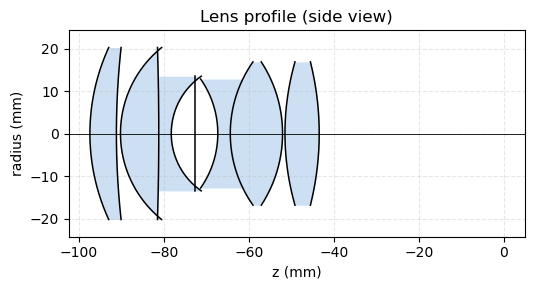

In [5]:
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)


def spherical_profile(curvature, z_surface, aperture, samples=240):
    if aperture <= 0.0:
        return None
    r = np.linspace(-aperture, aperture, samples)
    if abs(curvature) < 1e-9:
        z = np.full_like(r, z_surface, dtype=float)
    else:
        radius = abs(curvature)
        z_center = z_surface + curvature
        sag = np.sqrt(np.clip(radius * radius - r * r, 0.0, None))
        z = z_center - np.sign(curvature) * sag
    return z, r


def add_lens_profile(ax, lens=LENS, *, samples=240, glass_color="#71a7dd", glass_alpha=0.35, z_offset=0.0):
    surfaces = []
    z_surface = LENS_SURFACE_Z[0]
    for curvature, thickness, n_next, aperture in lens:
        profile = spherical_profile(curvature, z_surface, aperture, samples=samples)
        surfaces.append((curvature, z_surface, aperture, n_next))
        if profile is not None:
            z_vals, r_vals = profile
            ax.plot(z_vals - z_offset, r_vals, color="black", linewidth=1.1)
        z_surface += thickness

    for idx in range(len(surfaces) - 1):
        curvature_a, z_a, aperture_a, n_medium = surfaces[idx]
        curvature_b, z_b, aperture_b, _ = surfaces[idx + 1]
        if n_medium <= N_AIR + 1e-6:
            continue
        aperture_fill = min(aperture_a, aperture_b)
        if aperture_fill <= 0.0:
            continue
        profile_a = spherical_profile(curvature_a, z_a, aperture_fill, samples=samples)
        profile_b = spherical_profile(curvature_b, z_b, aperture_fill, samples=samples)
        if profile_a is None or profile_b is None:
            continue
        z_left, r_vals = profile_a
        z_right, _ = profile_b
        z_min = np.minimum(z_left, z_right) - z_offset
        z_max = np.maximum(z_left, z_right) - z_offset
        ax.fill_betweenx(r_vals, z_min, z_max, color=glass_color, alpha=glass_alpha, linewidth=0.0)
    surfaces_offset = [(curvature, z - z_offset, aperture, n_next) for curvature, z, aperture, n_next in surfaces]
    return surfaces_offset


 # Example usage: create a figure, call the helper, and format the plot outside the function.
fig, ax = plt.subplots(figsize=(8.0, 3.0))
add_lens_profile(ax)
ax.axhline(0.0, color="black", linewidth=0.6)
ax.set_title("Lens profile (side view)")
ax.set_xlabel("z (mm)")
ax.set_ylabel("radius (mm)")
ax.set_xlim(LENS_SURFACE_Z[0] - 5.0, 5.0)
ax.set_ylim(-APERTURE_RADIUS * 1.8, APERTURE_RADIUS * 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Precomputed surfaces and media are available via compute_lens_surfaces().
def trace_ray_verbose_reverse(ray_origin, target_point):
    """Verbose reverse-direction variant of trace_ray."""
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy(),
            "failure_index": -1
        }
    direction /= norm_dir
    n_current = LENS_MEDIA_AFTER[-1]
    for idx in range(len(LENS) - 1, -1, -1):
        z_surface = LENS_SURFACE_Z[idx]
        curvature, thickness, n_next, aperture = LENS[idx]
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy(),
                "failure_index": idx
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, idx):
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        n_target = LENS_MEDIA_BEFORE[idx]
        if n_target <= 0.0:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "invalid_medium",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        eta = n_current / n_target
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_target
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None,
        "failure_index": None
    }

In [7]:
sony_sensor_width = 35.9
sony_sensor_height = 24.0
aspect = 3 / 2
sensor_height = min(sony_sensor_height, sony_sensor_width / aspect)
sensor_width  = sensor_height * aspect

SENSOR_WIDTH_MM = sensor_width
SENSOR_HEIGHT_MM = sensor_height

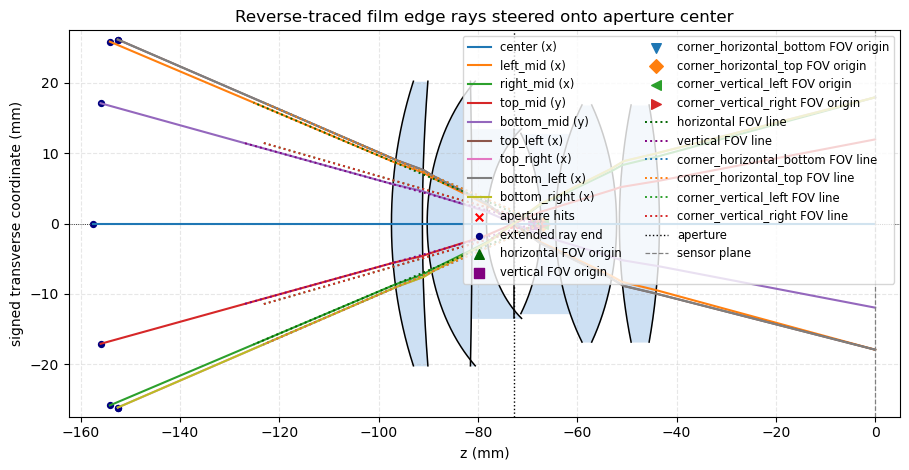

Field-of-view summary:
Sensor plane position [mm]: 0.000000
  Horizontal FOV: 33.330° (0.581722 rad)
    Origin (midpoint) [mm]: (np.float64(0.0), np.float64(0.0), np.float64(-67.689466))
  Vertical FOV: 22.138° (0.386386 rad)
    Origin (midpoint) [mm]: (np.float64(0.0), np.float64(0.0), np.float64(-68.515685))
  Corner Horizontal FOV (bottom edge): 33.343° (0.581946 rad)
    Origin (midpoint) [mm]: (np.float64(0.0), np.float64(-0.003981), np.float64(-66.881711))
  Corner Horizontal FOV (top edge): 33.343° (0.581946 rad)
    Origin (midpoint) [mm]: (np.float64(0.0), np.float64(0.003981), np.float64(-66.881711))
  Corner Vertical FOV (left edge): 22.053° (0.384897 rad)
    Origin (midpoint) [mm]: (np.float64(0.005971), np.float64(0.0), np.float64(-66.901247))
  Corner Vertical FOV (right edge): 22.053° (0.384897 rad)
    Origin (midpoint) [mm]: (np.float64(-0.005971), np.float64(0.0), np.float64(-66.901247))
  Corner Horizontal FOV (avg corners): 33.343° (0.581946 rad)
    Origin (aver

{'edge_ray_summary': {'center': {'error_mm': 0.0,
   'converged': True,
   'offsets': (np.float64(0.0), np.float64(0.0)),
   'dominant_axis': 'x',
   'film_point_mm': (0.0, 0.0),
   'aperture_offset_mm': (np.float64(0.0), np.float64(0.0)),
   'aperture_hit_mm': (np.float64(0.0),
    np.float64(0.0),
    np.float64(-72.785458)),
   'front_direction': (np.float64(0.0), np.float64(0.0), np.float64(-1.0))},
  'left_mid': {'error_mm': 0.000184748352054509,
   'converged': True,
   'offsets': (np.float64(0.192188), np.float64(0.0)),
   'dominant_axis': 'x',
   'film_point_mm': (-17.95, 0.0),
   'aperture_offset_mm': (np.float64(-0.000185), np.float64(0.0)),
   'aperture_hit_mm': (np.float64(-0.000185),
    np.float64(0.0),
    np.float64(-72.785458)),
   'front_direction': (np.float64(0.286777),
    np.float64(0.0),
    np.float64(-0.957997))},
  'right_mid': {'error_mm': 0.000184748352054509,
   'converged': True,
   'offsets': (np.float64(-0.192188), np.float64(0.0)),
   'dominant_axis': '

In [8]:
APERTURE_ELEMENT_INDEX = 5
APERTURE_Z_MM = LENS_SURFACE_Z[APERTURE_ELEMENT_INDEX]
t_focus_distance = 45.0
SENSOR_PLANE_OFFSET_MM = 335.598 / (t_focus_distance + 15.4) + 37.887
SENSOR_PLANE_Z_MM = LENS_SURFACE_Z[-1] + SENSOR_PLANE_OFFSET_MM
RAY_EXTENSION_MM = 60.0

AXIS_NAMES = ("x", "y")

def choose_major_axis(point):
    x, y = point
    if abs(x) >= abs(y):
        return 0
    return 1

def normalize(vec, eps=1e-9):
    vec = np.asarray(vec, dtype=float)
    mag = np.linalg.norm(vec)
    if mag < eps:
        return vec
    return vec / mag

def compute_ray_intersection(p1, d1, p2, d2, eps=1e-8):
    u = normalize(d1)
    v = normalize(d2)
    w0 = np.asarray(p1, dtype=float) - np.asarray(p2, dtype=float)
    a = np.dot(u, u)
    b = np.dot(u, v)
    c = np.dot(v, v)
    d = np.dot(u, w0)
    e = np.dot(v, w0)
    denom = a * c - b * b
    if abs(denom) < eps:
        t1 = -d / a if a > eps else 0.0
        t2 = 0.0
    else:
        t1 = (b * e - c * d) / denom
        t2 = (a * e - b * d) / denom
    point_1 = np.asarray(p1, dtype=float) + t1 * u
    point_2 = np.asarray(p2, dtype=float) + t2 * v
    midpoint = 0.5 * (point_1 + point_2)
    separation = float(np.linalg.norm(point_1 - point_2))
    return {
        "point_on_ray_1": point_1,
        "point_on_ray_2": point_2,
        "midpoint": midpoint,
        "separation": separation,
        "parameters": (t1, t2)
    }

def evaluate_reverse_ray(origin_xy, direction_xy, base_direction_z=-1.0):
    origin = np.array([origin_xy[0], origin_xy[1], SENSOR_PLANE_Z_MM], dtype=float)
    target = origin + np.array([direction_xy[0], direction_xy[1], base_direction_z], dtype=float)
    trace_data = trace_ray_verbose_reverse(origin, target)
    path = trace_data.get("path")
    if path is None or path.shape[0] <= (len(LENS) - APERTURE_ELEMENT_INDEX):
        aperture_hit = None
        aperture_offset = None
    else:
        path_index = len(LENS) - APERTURE_ELEMENT_INDEX
        aperture_hit = path[path_index]
        aperture_offset = aperture_hit[:2].copy()
    return {
        "origin": origin,
        "target": target,
        "trace": trace_data,
        "aperture_hit": aperture_hit,
        "aperture_offset": aperture_offset
    }

# Greedy divide-and-conquer search to steer a reverse ray onto the aperture center.
def steer_ray_to_aperture(origin_xy, *, initial_step=0.05, tolerance=5e-3, min_step=1e-5, max_iterations=150):
    offsets = np.zeros(2, dtype=float)
    best_eval = None
    best_error = np.inf
    step = float(initial_step)
    history = []

    base_eval = evaluate_reverse_ray(origin_xy, offsets)
    if base_eval["aperture_offset"] is not None:
        best_eval = base_eval
        best_error = float(np.linalg.norm(base_eval["aperture_offset"]))

    for iteration in range(max_iterations):
        history.append({
            "iteration": iteration,
            "offsets": offsets.copy(),
            "error": best_error
        })
        improved = False
        for axis in range(2):
            for sign in (1.0, -1.0):
                trial_offsets = offsets.copy()
                trial_offsets[axis] += sign * step
                trial_eval = evaluate_reverse_ray(origin_xy, trial_offsets)
                trial_offset = trial_eval["aperture_offset"]
                if trial_offset is None:
                    continue
                trial_error = float(np.linalg.norm(trial_offset))
                if trial_error < best_error - 1e-9:
                    offsets = trial_offsets
                    best_error = trial_error
                    best_eval = trial_eval
                    improved = True
                    break
            if improved:
                break
        if best_error <= tolerance:
            break
        if not improved:
            step *= 0.5
            if step < min_step:
                break
    if best_eval is None:
        best_eval = evaluate_reverse_ray(origin_xy, offsets)
        if best_eval["aperture_offset"] is not None:
            best_error = float(np.linalg.norm(best_eval["aperture_offset"]))
    return {
        "origin_xy": tuple(origin_xy),
        "offsets": offsets,
        "error": best_error,
        "step": step,
        "history": history,
        "evaluation": best_eval,
        "converged": best_eval is not None and best_eval["aperture_offset"] is not None and best_error <= tolerance
    }

half_width = 0.5 * SENSOR_WIDTH_MM
half_height = 0.5 * SENSOR_HEIGHT_MM
film_edge_points = [
    ("center", (0.0, 0.0)),
    ("left_mid", (-half_width, 0.0)),
    ("right_mid", (half_width, 0.0)),
    ("top_mid", (0.0, half_height)),
    ("bottom_mid", (0.0, -half_height)),
    ("top_left", (-half_width, half_height)),
    ("top_right", (half_width, half_height)),
    ("bottom_left", (-half_width, -half_height)),
    ("bottom_right", (half_width, -half_height))
]

edge_ray_solutions = {}
for name, point in film_edge_points:
    solution = steer_ray_to_aperture(point)
    axis_index = choose_major_axis(point)
    solution["dominant_axis"] = axis_index
    solution["film_point"] = tuple(point)
    edge_ray_solutions[name] = solution

fig, ax = plt.subplots(figsize=(9.2, 4.8))
add_lens_profile(ax)
ax.axhline(0.0, color="black", linewidth=0.6, linestyle=":")
max_abs_extent = max(APERTURE_RADIUS * 1.2, half_width, half_height)
min_z = float(np.min(LENS_SURFACE_Z))
max_z = float(SENSOR_PLANE_Z_MM)
aperture_markers_z = []
aperture_markers_vals = []
extension_markers_z = []
extension_markers_vals = []
fov_scatter = {}

for name, solution in edge_ray_solutions.items():
    eval_data = solution["evaluation"]
    if eval_data is None:
        continue
    trace_payload = eval_data["trace"]
    path = trace_payload.get("path") if trace_payload is not None else None
    if path is None:
        continue
    axis_index = solution.get("dominant_axis", 0)
    axis_name = AXIS_NAMES[axis_index]
    extended_path = path
    result_payload = trace_payload.get("result") if trace_payload is not None else None
    result_position = None
    result_direction = None
    if result_payload:
        result_position = result_payload.get("position")
        result_direction = normalize(result_payload.get("direction"))
    if result_position is not None and result_direction is not None:
        extension_point = np.array(result_position, dtype=float) + result_direction * RAY_EXTENSION_MM
        extended_path = np.vstack([extended_path, extension_point])
        extension_markers_z.append(extension_point[2])
        extension_markers_vals.append(extension_point[axis_index])
        solution["extended_point"] = extension_point
    else:
        solution["extended_point"] = None
    signed_vals = extended_path[:, axis_index]
    z_vals = extended_path[:, 2]
    max_abs_extent = max(max_abs_extent, float(np.max(np.abs(signed_vals))))
    min_z = min(min_z, float(np.min(z_vals)))
    max_z = max(max_z, float(np.max(z_vals)))
    ax.plot(z_vals, signed_vals, label=f"{name} ({axis_name})")
    aperture_hit = eval_data.get("aperture_hit")
    if aperture_hit is not None:
        aperture_markers_z.append(aperture_hit[2])
        aperture_markers_vals.append(aperture_hit[axis_index])
    solution["result_position"] = result_position
    solution["result_direction"] = result_direction
    solution["extended_path"] = extended_path
ax.scatter(aperture_markers_z, aperture_markers_vals, color="red", s=30, marker="x", label="aperture hits")
if extension_markers_z:
    ax.scatter(extension_markers_z, extension_markers_vals, color="navy", s=18, marker="o", label="extended ray end")

def compute_fov_entry(name_pos_a, name_pos_b, axis_index, label):
    sol_a = edge_ray_solutions.get(name_pos_a)
    sol_b = edge_ray_solutions.get(name_pos_b)
    if sol_a is None or sol_b is None:
        return None
    dir_a = sol_a.get("result_direction")
    dir_b = sol_b.get("result_direction")
    pos_a = sol_a.get("result_position")
    pos_b = sol_b.get("result_position")
    if dir_a is None or dir_b is None or pos_a is None or pos_b is None:
        return None
    dir_a = normalize(dir_a)
    dir_b = normalize(dir_b)
    dot = float(np.clip(np.dot(dir_a, dir_b), -1.0, 1.0))
    angle_rad = float(np.arccos(dot))
    intersection = compute_ray_intersection(pos_a, dir_a, pos_b, dir_b)
    midpoint = intersection["midpoint"]
    if label is not None:
        if label not in fov_scatter:
            fov_scatter[label] = []
        fov_scatter[label].append((midpoint[2], midpoint[axis_index]))
    return {
        "angle_deg": np.degrees(angle_rad),
        "angle_rad": angle_rad,
        "intersection": midpoint,
        "separation_mm": intersection["separation"],
        "ray_a_name": name_pos_a,
        "ray_b_name": name_pos_b,
        "dir_a": dir_a,
        "dir_b": dir_b,
        "axis_index": axis_index
    }

fov_results = {
    "horizontal": compute_fov_entry("left_mid", "right_mid", 0, "horizontal"),
    "vertical": compute_fov_entry("bottom_mid", "top_mid", 1, "vertical"),
    "corner_horizontal_bottom": compute_fov_entry("bottom_left", "bottom_right", 0, "corner_horizontal_bottom"),
    "corner_horizontal_top": compute_fov_entry("top_left", "top_right", 0, "corner_horizontal_top"),
    "corner_vertical_left": compute_fov_entry("bottom_left", "top_left", 1, "corner_vertical_left"),
    "corner_vertical_right": compute_fov_entry("bottom_right", "top_right", 1, "corner_vertical_right")
}

corner_horizontal_entries = [fov_results.get("corner_horizontal_bottom"), fov_results.get("corner_horizontal_top")]
corner_horizontal_entries = [entry for entry in corner_horizontal_entries if entry is not None]
corner_horizontal_summary = None
if corner_horizontal_entries:
    corner_angles = np.array([entry["angle_rad"] for entry in corner_horizontal_entries], dtype=float)
    corner_angle_rad = float(np.mean(corner_angles))
    corner_horizontal_summary = {
        "angle_rad": corner_angle_rad,
        "angle_deg": float(np.degrees(corner_angle_rad)),
        "intersection": np.mean([entry["intersection"] for entry in corner_horizontal_entries], axis=0),
        "separation_mm": float(np.mean([entry["separation_mm"] for entry in corner_horizontal_entries])),
        "pair_sources": tuple((entry["ray_a_name"], entry["ray_b_name"]) for entry in corner_horizontal_entries)
    }

corner_vertical_entries = [fov_results.get("corner_vertical_left"), fov_results.get("corner_vertical_right")]
corner_vertical_entries = [entry for entry in corner_vertical_entries if entry is not None]
corner_vertical_summary = None
if corner_vertical_entries:
    corner_angles = np.array([entry["angle_rad"] for entry in corner_vertical_entries], dtype=float)
    corner_angle_rad = float(np.mean(corner_angles))
    corner_vertical_summary = {
        "angle_rad": corner_angle_rad,
        "angle_deg": float(np.degrees(corner_angle_rad)),
        "intersection": np.mean([entry["intersection"] for entry in corner_vertical_entries], axis=0),
        "separation_mm": float(np.mean([entry["separation_mm"] for entry in corner_vertical_entries])),
        "pair_sources": tuple((entry["ray_a_name"], entry["ray_b_name"]) for entry in corner_vertical_entries)
    }

scatter_styles = {
    "horizontal": ("darkgreen", "^"),
    "vertical": ("purple", "s"),
    "corner_horizontal_bottom": ("#1f77b4", "v"),
    "corner_horizontal_top": ("#ff7f0e", "D"),
    "corner_vertical_left": ("#2ca02c", "<"),
    "corner_vertical_right": ("#d62728", ">")
}
for axis_label, entries in fov_scatter.items():
    if not entries:
        continue
    entries_arr = np.array(entries, dtype=float)
    color, marker = scatter_styles.get(axis_label, ("black", "o"))
    ax.scatter(entries_arr[:, 0], entries_arr[:, 1], color=color, s=48, marker=marker, label=f"{axis_label} FOV origin")

fov_line_labels = set()
fov_colors = {
    "horizontal": "darkgreen",
    "vertical": "purple",
    "corner_horizontal_bottom": "#1f77b4",
    "corner_horizontal_top": "#ff7f0e",
    "corner_vertical_left": "#2ca02c",
    "corner_vertical_right": "#d62728"
}
for axis_label, result in fov_results.items():
    if result is None:
        continue
    origin = result["intersection"]
    axis_index = result["axis_index"]
    color = fov_colors.get(axis_label, "black")
    label = f"{axis_label} FOV line"
    for dir_vec in (result["dir_a"], result["dir_b"]):
        if dir_vec is None:
            continue
        line_pts = np.vstack([origin, origin + dir_vec * RAY_EXTENSION_MM])
        plot_label = label if label not in fov_line_labels else None
        ax.plot(line_pts[:, 2], line_pts[:, axis_index], linestyle=":", linewidth=1.4, color=color, label=plot_label)
        fov_line_labels.add(label)

ax.axvline(APERTURE_Z_MM, color="black", linestyle=":", linewidth=1.0, label="aperture")
ax.axvline(SENSOR_PLANE_Z_MM, color="gray", linestyle="--", linewidth=0.9, label="sensor plane")
ax.set_xlim(min_z - 5.0, max_z + 5.0)
ax.set_ylim(-max_abs_extent * 1.05, max_abs_extent * 1.05)
ax.set_xlabel("z (mm)")
ax.set_ylabel("signed transverse coordinate (mm)")
ax.set_title("Reverse-traced film edge rays steered onto aperture center")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper right", fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

print("Field-of-view summary:")
print(f"Sensor plane position [mm]: {SENSOR_PLANE_Z_MM:.6f}")
summary_entries = [
    ("horizontal", "Horizontal FOV"),
    ("vertical", "Vertical FOV"),
    ("corner_horizontal_bottom", "Corner Horizontal FOV (bottom edge)"),
    ("corner_horizontal_top", "Corner Horizontal FOV (top edge)"),
    ("corner_vertical_left", "Corner Vertical FOV (left edge)"),
    ("corner_vertical_right", "Corner Vertical FOV (right edge)")
]
for key, label in summary_entries:
    result = fov_results.get(key)
    if result is None:
        print(f"  {label}: unavailable")
        continue
    origin = tuple(np.round(result["intersection"], 6))
    print(f"  {label}: {result['angle_deg']:.3f}° ({result['angle_rad']:.6f} rad)")
    print(f"    Origin (midpoint) [mm]: {origin}")
if corner_horizontal_summary is not None:
    origin = tuple(np.round(corner_horizontal_summary["intersection"], 6))
    pair_desc = ", ".join(" & ".join(pair) for pair in corner_horizontal_summary["pair_sources"])
    print(f"  Corner Horizontal FOV (avg corners): {corner_horizontal_summary['angle_deg']:.3f}° ({corner_horizontal_summary['angle_rad']:.6f} rad)")
    print(f"    Origin (average midpoint) [mm]: {origin}")
    print(f"    Sources: {pair_desc}")
if corner_vertical_summary is not None:
    origin = tuple(np.round(corner_vertical_summary["intersection"], 6))
    pair_desc = ", ".join(" & ".join(pair) for pair in corner_vertical_summary["pair_sources"])
    print(f"  Corner Vertical FOV (avg corners): {corner_vertical_summary['angle_deg']:.3f}° ({corner_vertical_summary['angle_rad']:.6f} rad)")
    print(f"    Origin (average midpoint) [mm]: {origin}")
    print(f"    Sources: {pair_desc}")

edge_ray_summary = {}
for name, solution in edge_ray_solutions.items():
    eval_data = solution["evaluation"]
    aperture_offset = None
    aperture_hit = None
    front_direction = None
    if eval_data is not None:
        if eval_data["aperture_offset"] is not None:
            aperture_offset = tuple(np.round(eval_data["aperture_offset"], 6))
        if eval_data["aperture_hit"] is not None:
            aperture_hit = tuple(np.round(eval_data["aperture_hit"], 6))
        trace_payload = eval_data["trace"]
        result_payload = trace_payload.get("result") if trace_payload is not None else None
        if result_payload and result_payload.get("direction") is not None:
            front_direction = tuple(np.round(normalize(result_payload["direction"]), 6))
    axis_index = solution.get("dominant_axis", 0)
    axis_name = AXIS_NAMES[axis_index]
    edge_ray_summary[name] = {
        "error_mm": float(solution["error"]),
        "converged": solution["converged"],
        "offsets": tuple(np.round(solution["offsets"], 6)),
        "dominant_axis": axis_name,
        "film_point_mm": solution.get("film_point"),
        "aperture_offset_mm": aperture_offset,
        "aperture_hit_mm": aperture_hit,
        "front_direction": front_direction
    }

fov_export = {}
for key, value in fov_results.items():
    if value is None:
        fov_export[key] = None
        continue
    fov_export[key] = {
        "angle_deg": float(np.round(value["angle_deg"], 6)),
        "angle_rad": float(value["angle_rad"]),
        "intersection_mm": tuple(np.round(value["intersection"], 6)),
        "separation_mm": float(value["separation_mm"]),
        "ray_pair": (value["ray_a_name"], value["ray_b_name"])
    }
if corner_horizontal_summary is not None:
    fov_export["corner_horizontal_average"] = {
        "angle_deg": float(np.round(corner_horizontal_summary["angle_deg"], 6)),
        "angle_rad": float(corner_horizontal_summary["angle_rad"]),
        "intersection_mm": tuple(np.round(corner_horizontal_summary["intersection"], 6)),
        "separation_mm": float(corner_horizontal_summary["separation_mm"]),
        "ray_pairs": tuple(corner_horizontal_summary["pair_sources"])
    }
if corner_vertical_summary is not None:
    fov_export["corner_vertical_average"] = {
        "angle_deg": float(np.round(corner_vertical_summary["angle_deg"], 6)),
        "angle_rad": float(corner_vertical_summary["angle_rad"]),
        "intersection_mm": tuple(np.round(corner_vertical_summary["intersection"], 6)),
        "separation_mm": float(corner_vertical_summary["separation_mm"]),
        "ray_pairs": tuple(corner_vertical_summary["pair_sources"])
    }
{
    "edge_ray_summary": edge_ray_summary,
    "fov_results": fov_export
}

In [9]:
import time
from pathlib import Path


def steer_ray_to_aperture_fast(origin_xy, *, offsets=None, initial_step=0.05, tolerance=5e-3, min_step=1e-5, max_iterations=120):
    """Greedy steering with a reusable seed and without tracking full history."""
    base_offsets = np.array(offsets if offsets is not None else (0.0, 0.0), dtype=float)
    current_offsets = base_offsets.copy()
    step = float(initial_step)
    best_eval = evaluate_reverse_ray(origin_xy, current_offsets)
    best_offset_vec = best_eval["aperture_offset"]
    best_error = float(np.linalg.norm(best_offset_vec)) if best_offset_vec is not None else np.inf
    best_offsets = current_offsets.copy()
    for _ in range(max_iterations):
        improved = False
        for axis in range(2):
            for sign in (1.0, -1.0):
                trial_offsets = current_offsets.copy()
                trial_offsets[axis] += sign * step
                trial_eval = evaluate_reverse_ray(origin_xy, trial_offsets)
                trial_offset = trial_eval["aperture_offset"]
                if trial_offset is None:
                    continue
                trial_error = float(np.linalg.norm(trial_offset))
                if trial_error < best_error - 1e-12:
                    current_offsets = trial_offsets
                    best_offsets = trial_offsets.copy()
                    best_eval = trial_eval
                    best_error = trial_error
                    improved = True
                    break
            if improved:
                break
        if best_error <= tolerance:
            break
        if not improved:
            step *= 0.5
            if step < min_step:
                break
    converged = best_eval["aperture_offset"] is not None and best_error <= tolerance
    return {
        "offsets": best_offsets,
        "evaluation": best_eval,
        "error": best_error,
        "converged": converged,
        "step": step
    }


def generate_sensor_ray_maps(width=800, height=600, *, initial_step=0.05, tolerance=5e-3, min_step=1e-5, max_iterations=80, direction_filename="ray_directions_800x600.png", exit_filename="ray_exit_positions_800x600.png"):
    """Trace a grid of sensor rays, export direction and exit-point images, and return data arrays."""
    x_step = SENSOR_WIDTH_MM / width
    y_step = SENSOR_HEIGHT_MM / height
    x_coords = np.linspace(-half_width + 0.5 * x_step, half_width - 0.5 * x_step, width)
    y_coords = np.linspace(-half_height + 0.5 * y_step, half_height - 0.5 * y_step, height)
    direction_map = np.zeros((height, width, 3), dtype=np.float32)
    exit_map = np.zeros((height, width, 3), dtype=np.float32)
    converged_mask = np.zeros((height, width), dtype=bool)
    error_map = np.full((height, width), np.inf, dtype=np.float32)
    offset_map = np.zeros((height, width, 2), dtype=np.float32)
    aperture_offset_map = np.full((height, width, 2), np.nan, dtype=np.float32)
    step_map = np.zeros((height, width), dtype=np.float32)
    start_time = time.time()
    row_report_interval = max(1, height // 20)
    for j, sensor_y in enumerate(y_coords):
        for i, sensor_x in enumerate(x_coords):
            # Do not reuse seeds between neighbors to avoid grid artifacts in the direction map.
            result = steer_ray_to_aperture_fast(
                (sensor_x, sensor_y),
                offsets=None,
                initial_step=initial_step,
                tolerance=tolerance,
                min_step=min_step,
                max_iterations=max_iterations
            )
            offset_map[j, i] = result["offsets"]
            step_map[j, i] = result["step"]
            error_map[j, i] = result["error"]
            eval_payload = result["evaluation"]
            aperture_offset = eval_payload.get("aperture_offset") if eval_payload is not None else None
            if aperture_offset is not None:
                aperture_offset_map[j, i] = aperture_offset
            trace_payload = eval_payload.get("trace") if eval_payload is not None else None
            result_payload = trace_payload.get("result") if trace_payload is not None else None
            if result_payload is None:
                continue
            dir_vec = result_payload.get("direction")
            pos_vec = result_payload.get("position")
            if dir_vec is None or pos_vec is None:
                continue
            direction_map[j, i] = normalize(np.asarray(dir_vec, dtype=float))  # sensor-to-scene direction
            exit_map[j, i] = np.asarray(pos_vec, dtype=float)
            converged_mask[j, i] = result["converged"]
        if (j + 1) % row_report_interval == 0 or (j + 1) == height:
            elapsed = time.time() - start_time
            print(f"Processed {j + 1}/{height} rows ({(j + 1) / height:.1%}) in {elapsed:.1f} s")
    direction_map[~converged_mask] = 0.0
    exit_map[~converged_mask] = 0.0
    direction_img = np.clip((direction_map + 1.0) * 0.5, 0.0, 1.0)
    direction_img_uint8 = (direction_img * 255.0 + 0.5).astype(np.uint8)
    alpha_channel = np.where(converged_mask, 255, 0).astype(np.uint8)
    direction_rgba = np.dstack([direction_img_uint8, alpha_channel])
    exit_img = np.zeros_like(exit_map, dtype=np.float32)
    min_pos = None
    max_pos = None
    if np.any(converged_mask):
        valid_positions = exit_map[converged_mask]
        min_pos = valid_positions.min(axis=0)
        max_pos = valid_positions.max(axis=0)
        span = np.maximum(max_pos - min_pos, 1e-6)
        exit_img[converged_mask] = (exit_map[converged_mask] - min_pos) / span
    exit_img_uint8 = (np.clip(exit_img, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8)
    exit_rgba = np.dstack([exit_img_uint8, alpha_channel])
    output_dir = Path(r"C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\lens_distortion")
    direction_path = output_dir / direction_filename
    exit_path = output_dir / exit_filename
    Image.fromarray(direction_rgba, mode="RGBA").save(direction_path)
    Image.fromarray(exit_rgba, mode="RGBA").save(exit_path)
    converged_total = int(converged_mask.sum())
    total_rays = width * height
    print(f"Converged rays: {converged_total}/{total_rays}")
    if min_pos is not None and max_pos is not None:
        print(f"Exit position bounds (mm): min={min_pos}, max={max_pos}")
    return {
        "direction_map": direction_map,
        "exit_map": exit_map,
        "converged_mask": converged_mask,
        "error_map": error_map,
        "offset_map": offset_map,
        "aperture_offset_map": aperture_offset_map,
        "step_map": step_map,
        "direction_image_path": str(direction_path),
        "exit_image_path": str(exit_path),
        "exit_position_bounds_mm": None if min_pos is None else {"min": min_pos, "max": max_pos}
    }


ray_map_results = generate_sensor_ray_maps()
ray_map_results["direction_image_path"], ray_map_results["exit_image_path"]

Processed 30/600 rows (5.0%) in 308.3 s
Processed 60/600 rows (10.0%) in 612.8 s
Processed 60/600 rows (10.0%) in 612.8 s
Processed 90/600 rows (15.0%) in 898.6 s
Processed 90/600 rows (15.0%) in 898.6 s
Processed 120/600 rows (20.0%) in 1206.2 s
Processed 120/600 rows (20.0%) in 1206.2 s
Processed 150/600 rows (25.0%) in 1500.5 s
Processed 150/600 rows (25.0%) in 1500.5 s
Processed 180/600 rows (30.0%) in 1782.2 s
Processed 180/600 rows (30.0%) in 1782.2 s
Processed 210/600 rows (35.0%) in 2048.3 s
Processed 210/600 rows (35.0%) in 2048.3 s
Processed 240/600 rows (40.0%) in 2329.5 s
Processed 240/600 rows (40.0%) in 2329.5 s
Processed 270/600 rows (45.0%) in 2598.3 s
Processed 270/600 rows (45.0%) in 2598.3 s
Processed 300/600 rows (50.0%) in 2848.9 s
Processed 300/600 rows (50.0%) in 2848.9 s
Processed 330/600 rows (55.0%) in 3102.2 s
Processed 330/600 rows (55.0%) in 3102.2 s
Processed 360/600 rows (60.0%) in 3372.2 s
Processed 360/600 rows (60.0%) in 3372.2 s
Processed 390/600 rows

('C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\lens_distortion\\ray_directions_800x600.png',
 'C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\lens_distortion\\ray_exit_positions_800x600.png')

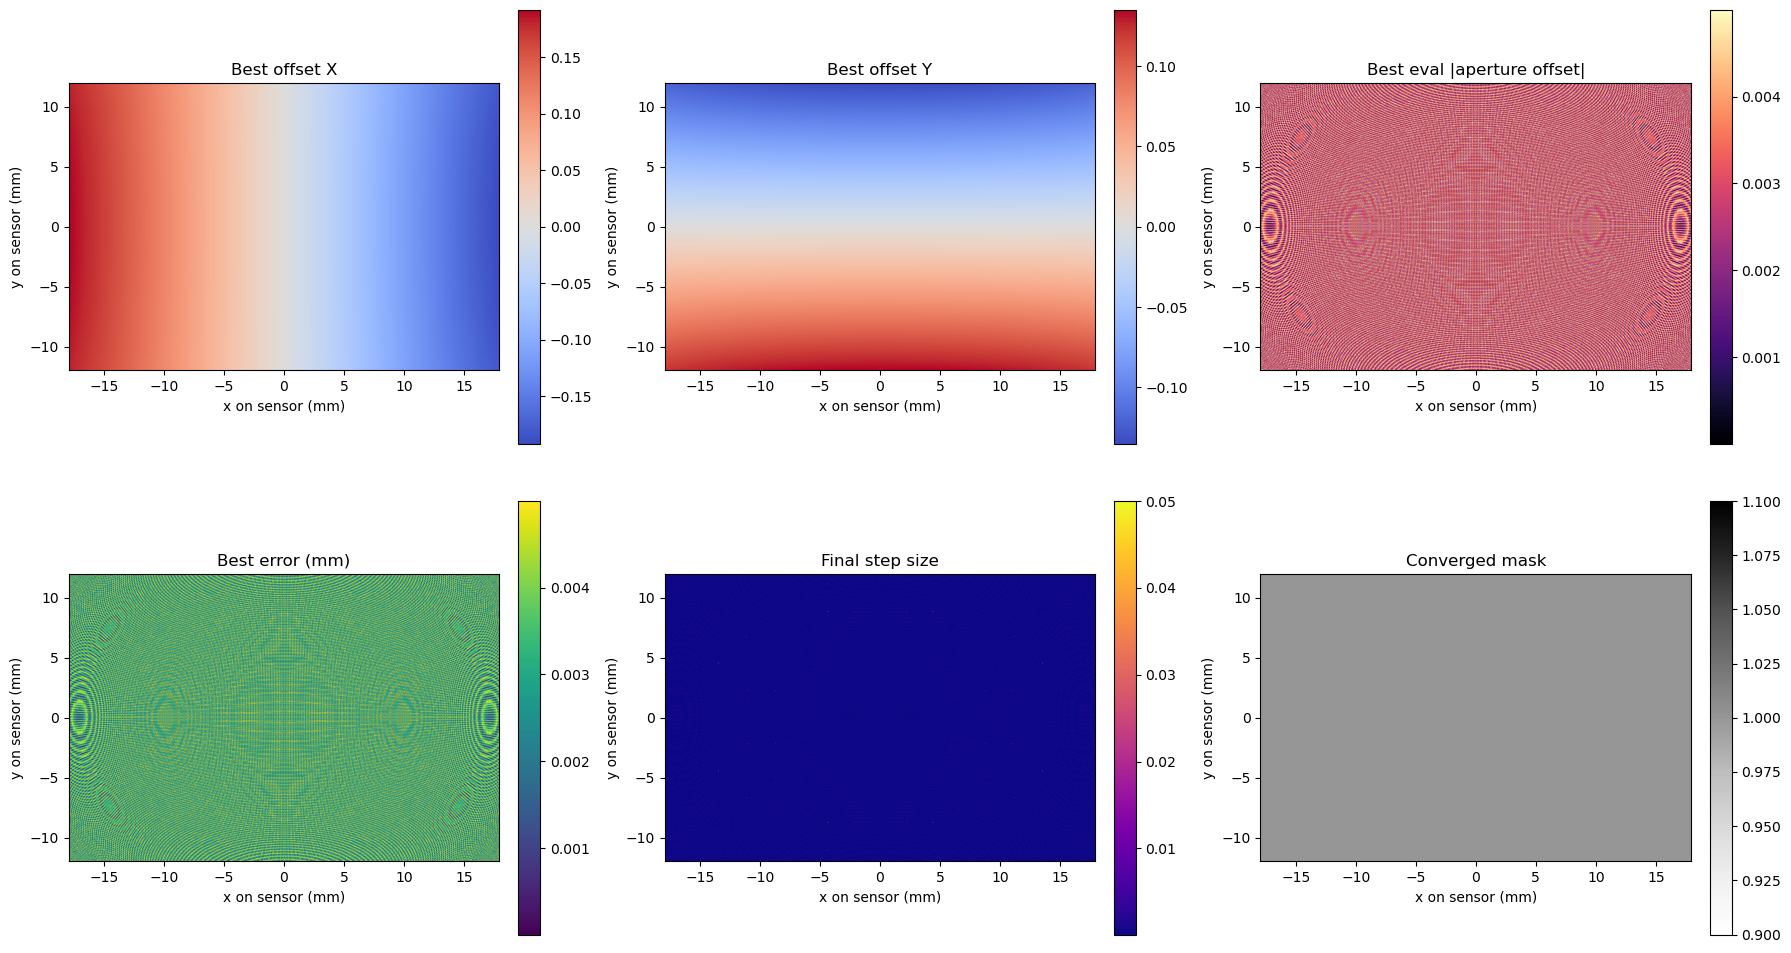

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize per-pixel optimization results using ray_map_results from cell 9.
required_keys = ["offset_map", "aperture_offset_map", "error_map", "converged_mask", "step_map"]
missing_keys = [k for k in required_keys if k not in ray_map_results]
if missing_keys:
    raise RuntimeError(f"ray_map_results is missing {missing_keys}. Rerun the map generation cell to populate them.")

offset_map = ray_map_results["offset_map"]
aperture_offset_map = ray_map_results["aperture_offset_map"]
error_map = ray_map_results["error_map"]
converged_mask = ray_map_results["converged_mask"]
step_map = ray_map_results["step_map"]

extent = [-half_width, half_width, -half_height, half_height]
nan_mask = np.where(converged_mask, 1.0, np.nan)
offset_x = offset_map[:, :, 0] * nan_mask
offset_y = offset_map[:, :, 1] * nan_mask
aperture_eval_mag = np.linalg.norm(aperture_offset_map, axis=2) * nan_mask
error_vis = error_map * nan_mask
step_vis = step_map * nan_mask
converged_vis = converged_mask.astype(float)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plots = [
    (offset_x, "Best offset X", "coolwarm"),
    (offset_y, "Best offset Y", "coolwarm"),
    (aperture_eval_mag, "Best eval |aperture offset|", "magma"),
    (error_vis, "Best error (mm)", "viridis"),
    (step_vis, "Final step size", "plasma"),
    (converged_vis, "Converged mask", "Greys")
]

for ax, (data, title, cmap) in zip(axes.ravel(), plots):
    im = ax.imshow(data, origin="lower", extent=extent, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x on sensor (mm)")
    ax.set_ylabel("y on sensor (mm)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

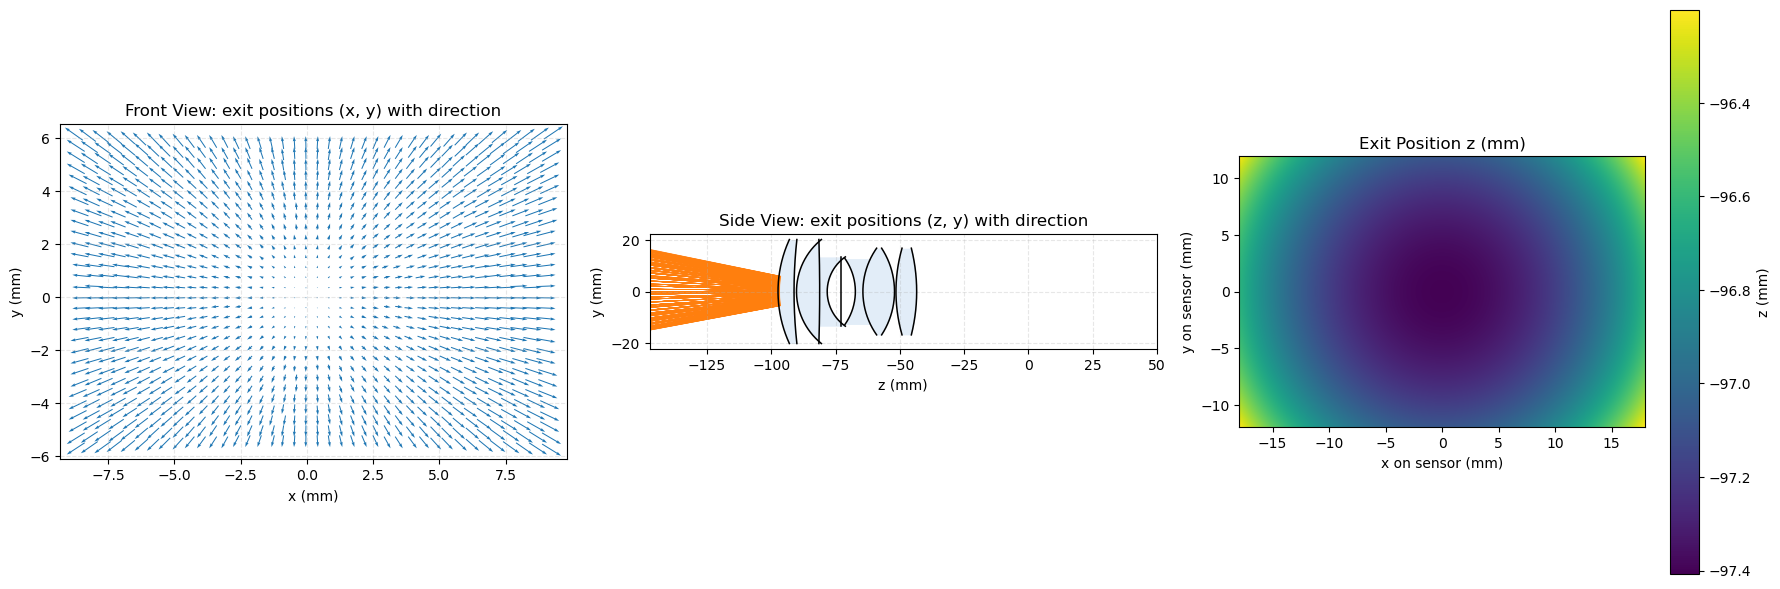

(1200, 'ray_directions_800x600.png', 'ray_exit_positions_800x600.png')

In [11]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

direction_image_path = Path(ray_map_results.get("direction_image_path", "ray_directions_800x600.png"))
exit_image_path = Path(ray_map_results.get("exit_image_path", "ray_exit_positions_800x600.png"))

def load_direction_and_exit_maps(direction_path, exit_path):
    direction_img = np.asarray(Image.open(direction_path).convert("RGBA"), dtype=np.float32) / 255.0
    direction_rgb = direction_img[..., :3]
    direction_alpha = direction_img[..., 3:4]
    direction_map = direction_rgb * 2.0 - 1.0
    exit_img = np.asarray(Image.open(exit_path).convert("RGBA"), dtype=np.float32) / 255.0
    exit_rgb = exit_img[..., :3]
    exit_bounds = ray_map_results.get("exit_position_bounds_mm") if 'ray_map_results' in globals() else None
    if exit_bounds is not None:
        min_pos = np.asarray(exit_bounds["min"], dtype=np.float32)
        max_pos = np.asarray(exit_bounds["max"], dtype=np.float32)
        span = np.maximum(max_pos - min_pos, 1e-6)
        exit_map = exit_rgb * span + min_pos
    else:
        exit_map = exit_rgb
    mask = (direction_alpha[..., 0] > 0.5)
    return direction_map, exit_map, mask

direction_map, exit_map, converged_mask = load_direction_and_exit_maps(direction_image_path, exit_image_path)

stride = 20
sample_mask = converged_mask[::stride, ::stride]
sample_positions = exit_map[::stride, ::stride, :]
sample_directions = direction_map[::stride, ::stride, :]
sample_positions = sample_positions[sample_mask]
sample_directions = sample_directions[sample_mask]

fig, axes = plt.subplots(1, 3, figsize=(18.0, 6.0))

# Front view: look down the optical axis (z).
ax_front = axes[0]
ax_front.set_title("Front View: exit positions (x, y) with direction")
ax_front.set_xlabel("x (mm)")
ax_front.set_ylabel("y (mm)")
if sample_positions.size > 0:
    ax_front.quiver(
        sample_positions[:, 0],
        sample_positions[:, 1],
        sample_directions[:, 0],
        sample_directions[:, 1],
        angles='xy',
        scale_units='xy',
        scale=0.4,
        color='tab:blue',
        width=0.002
    )
ax_front.set_aspect('equal', adjustable='box')
ax_front.grid(True, linestyle='--', alpha=0.3)

# Side view: yz plane using exit positions and direction components, with lens overlay.
ax_side = axes[1]
ax_side.set_title("Side View: exit positions (z, y) with direction")
ax_side.set_xlabel("z (mm)")
ax_side.set_ylabel("y (mm)")
add_lens_profile(ax_side, glass_alpha=0.2)
if sample_positions.size > 0:
    ax_side.quiver(
        sample_positions[:, 2],
        sample_positions[:, 1],
        sample_directions[:, 2],
        sample_directions[:, 1],
        angles='xy',
        scale_units='xy',
        scale=0.01,
        color='tab:orange',
        width=0.001
    )
    z_min = min(float(sample_positions[:, 2].min()), float(np.min(LENS_SURFACE_Z))) - 50.0
    z_max = max(float(sample_positions[:, 2].max()), float(SENSOR_PLANE_Z_MM)) + 50.0
    ax_side.set_xlim(z_min, z_max)
ax_side.set_aspect('equal', adjustable='box')
ax_side.grid(True, linestyle='--', alpha=0.3)

# Heatmap: exit position z-value over the sensor grid.
ax_heat = axes[2]
heatmap = exit_map[:, :, 2].copy()
heatmap[~converged_mask] = np.nan
extent = [-half_width, half_width, -half_height, half_height]
im = ax_heat.imshow(heatmap, extent=extent, origin='lower', cmap='viridis')
ax_heat.set_title("Exit Position z (mm)")
ax_heat.set_xlabel("x on sensor (mm)")
ax_heat.set_ylabel("y on sensor (mm)")
cbar = plt.colorbar(im, ax=ax_heat)
cbar.set_label("z (mm)")
ax_heat.grid(False)

plt.tight_layout()
plt.show()

sample_positions.shape[0], direction_image_path.name, exit_image_path.name